# Portfolio dashboard

One place to see how the portfolio is doing: what it holds, how its value has
moved as positions were added, and how it compares to a benchmark.

Everything comes from `PortfolioSummary.get_summary()` — the notebook only draws.

In [67]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from domain.transaction import Transaction
from domain.portfolio import Portfolio
from data.market_data import MarketDataFetcher
from reporting.summary import PortfolioSummary

pd.options.display.float_format = '{:,.2f}'.format

BENCHMARK = 'SPY'

# ── Your transactions. Edit these. ────────────────────────────────────
portfolio = Portfolio('ATK_1', 'USD', creation_date='2024-01-01')
portfolio.add_transaction(Transaction('aapl', '2024-01-02', 'BUY', 5, 185, 2, 'USD'))
portfolio.add_transaction(Transaction('msft', '2024-03-01', 'BUY', 3, 415, 2, 'USD'))
portfolio.add_transaction(Transaction('aapl', '2026-06-01', 'BUY', 1, 195, 2, 'USD'))

# Share the repo-root cache instead of starting a second one under notebooks/.
fetcher = MarketDataFetcher(cache_directory=os.path.join('..', 'cache'))
summary = PortfolioSummary(portfolio, fetcher=fetcher, benchmark_ticker=BENCHMARK).get_summary()

print('Ready.')

Ready.


## 1 · What's in the portfolio

In [68]:
v = summary['value_summary']

print(f"Current value    {v['Current Value']:>12,.2f}")
print(f"Total invested   {v['Total Invested']:>12,.2f}")
print(f"Total profit     {v['Total Profit']:>12,.2f}")
print(f"Total return     {v['Total Return Percentage']:>12.2%}")

pd.DataFrame(summary['positions'])[
    ['ticker', 'quantity', 'avg_cost', 'current_price',
     'current_value', 'unrealized_pnl', 'unrealized_pnl_pct', 'weight']
]

Current value        3,334.71
Total invested       2,365.00
Total profit           969.71
Total return          263.33%


KeyError: "['current_price'] not in index"

## 2 · Portfolio value over time

Value steps up when you put money in and drifts with the market in between.
Each dot is a transaction, so you can see positions being added.

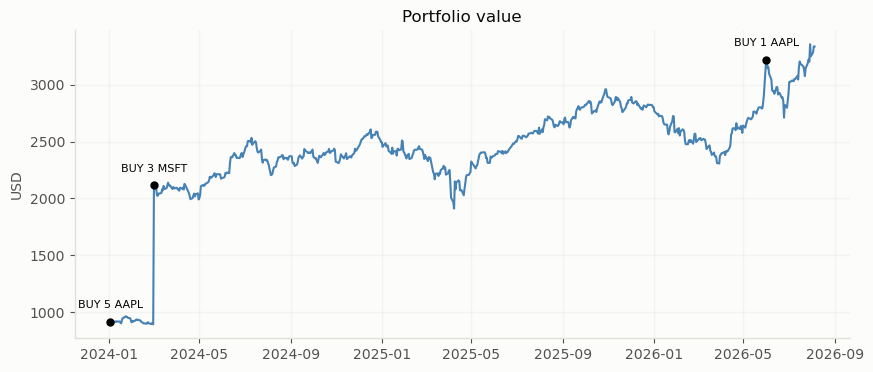

In [ ]:
value = summary['timeseries']['portfolio_value']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(value.index, value.values, linewidth=1.5, color='steelblue')

for tx in summary['transactions']:
    day = pd.Timestamp(tx['date'])
    slot = value.index.searchsorted(day)          # weekend trades snap forward
    if slot >= len(value.index):
        continue
    day = value.index[slot]
    ax.plot(day, value.loc[day], 'o', color='black', markersize=5, zorder=3)
    ax.annotate(f"{tx['type']} {tx['quantity']} {tx['ticker']}",
                (day, value.loc[day]), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)

ax.set_title('Portfolio value')
ax.set_ylabel('USD')
ax.grid(alpha=0.3)
plt.show()

## 3 · Performance vs benchmark

Both lines start at 100. This one ignores deposits — it only moves when the
market does, which is what makes it comparable to the benchmark.

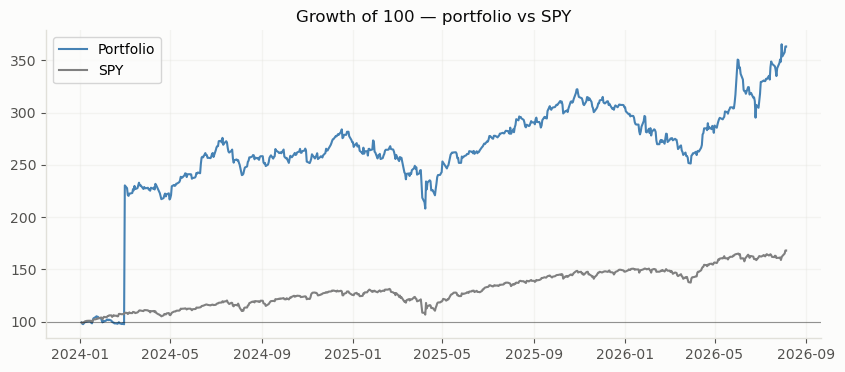

In [ ]:
port_growth = summary['timeseries']['growth_of_1usd']
bench_growth = summary['benchmark']['growth_of_1usd_benchmark'].reindex(port_growth.index).ffill()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(port_growth.index, port_growth.values, linewidth=1.5, label='Portfolio', color='steelblue')
ax.plot(bench_growth.index, bench_growth.values, linewidth=1.5, label=BENCHMARK, color='grey')
ax.axhline(100, color='black', linewidth=0.8, alpha=0.4)

ax.set_title(f'Growth of 100 — portfolio vs {BENCHMARK}')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [ ]:
m = summary['performance_metrics']
b = summary['benchmark']

pd.Series({
    'Portfolio total return':  v['Total Return Percentage'],
    f'{BENCHMARK} total return': b['benchmark_return'],
    'Outperformance':          b['outperformance'],
    '':                        float('nan'),
    'Annualized return':       m['Annualized Return'],
    'Volatility':              m['Volatility'],
    'Sharpe ratio':            m['Sharpe Ratio'],
    'Max drawdown':            m['Max Drawdown'],
    'Beta':                    b['beta'],
    'Correlation':             b['correlation'],
    'Time-weighted return':    m['Time Weighted Return'],
    'Money-weighted return':   m['Money Weighted return'],
}).to_frame('value')

,value
Portfolio total return,2.63
SPY total return,0.68
Outperformance,1.95
,NaN
Annualized return,0.62
Volatility,0.86
Sharpe ratio,0.72
Max drawdown,-0.27
Beta,1.19
Correlation,0.21


## 4 · Returns by period

In [ ]:
pd.Series(summary['period_returns']).to_frame('return')

,return
YTD,0.19
1M,0.10
3M,0.27
6M,0.27
1Y,0.28
5Y,2.63
Inception,2.63


## 5 · Transactions

In [ ]:
pd.DataFrame(summary['transactions'])

,date,ticker,type,quantity,price,fees,total_cost,currency
0,2024-01-02,AAPL,BUY,5,185,2,927,USD
1,2024-03-01,MSFT,BUY,3,415,2,1247,USD
2,2026-06-01,AAPL,BUY,1,195,2,197,USD


## 6 · Next step — news on these holdings

`holdings` is the list to feed the Yahoo Finance news lookup, whose headlines
then go to the local LLM for comment.

In [ ]:
holdings = [p['ticker'] for p in summary['positions']]
holdings

['AAPL', 'MSFT']